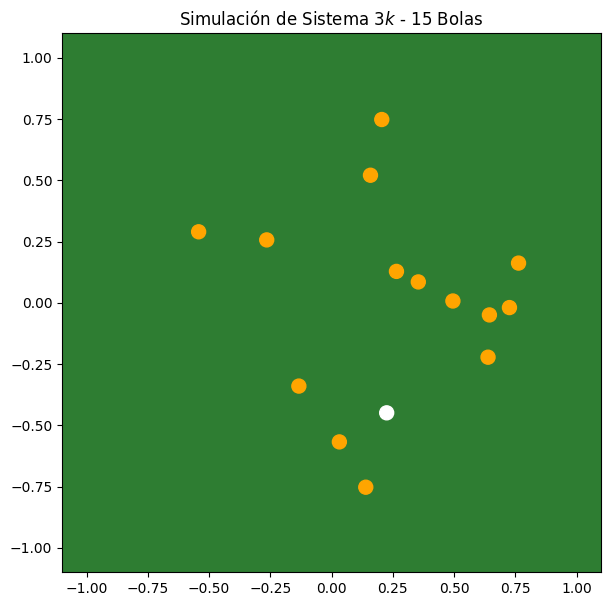

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

class PhysicsMathEngine:
    def __init__(self, k, dt=5e-5, m=0.17, R=0.0285):
        self.k = k
        self.dt = dt
        self.m = m
        self.R = R
        self.g = 9.81
        self.k_stiff = 1e6  # Rigidez para el potencial Phi
        self.mu = 0.1       # Coeficiente de fricción del paño
        
        # Estado [k, 6]: r, gamma, z, dr, dgamma, dz
        self.S = np.zeros((k, 6))
        
    def compute_exact_derivatives(self, S):
        """
        Calcula las aceleraciones (q'') despejando de tus ecuaciones:
        d/dt(dL/dq') - dL/dq = Q
        """
        r, gamma, z = S[:, 0], S[:, 1], S[:, 2]
        dr, dgamma, dz = S[:, 3], S[:, 4], S[:, 5]
        
        # --- 1. Términos de interacción (Gradiente de -Phi) ---
        # Convertimos a cartesianas solo para calcular la repulsión física
        x, y = r * np.cos(gamma), r * np.sin(gamma)
        pos_c = np.stack([x, y, z], axis=1)
        
        diff = pos_c[:, np.newaxis, :] - pos_c[np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=2) + np.eye(self.k)
        
        overlap = np.maximum(0, 2*self.R - dist)
        # Fuerza de repulsión (Penalty method)
        f_phi_mag = self.k_stiff * overlap 
        unit_vectors = diff / dist[:, :, np.newaxis]
        f_phi_cart = np.sum(f_phi_mag[:, :, np.newaxis] * unit_vectors, axis=1)

        # --- 2. Fuerzas Generalizadas Q (Fricción F * dr/dq) ---
        # Fuerza de fricción en cartesianas opuesta a la velocidad
        v_cart_x = dr * np.cos(gamma) - r * dgamma * np.sin(gamma)
        v_cart_y = dr * np.sin(gamma) + r * dgamma * np.cos(gamma)
        v_cart = np.stack([v_cart_x, v_cart_y, dz], axis=1)
        
        f_fric = -self.mu * v_cart
        
        # Fuerza total externa + interacción en cartesianas
        f_total = f_phi_cart + f_fric

        # --- 3. Despeje de q'' de tus ecuaciones ---
        
        # Para r: m*r'' = m*r*(gamma')^2 + F_r
        # Proyectamos f_total a dirección radial
        fr_ext = f_total[:, 0] * np.cos(gamma) + f_total[:, 1] * np.sin(gamma)
        ddr = (self.m * r * dgamma**2 + fr_ext) / self.m
        
        # Para gamma: m*r*gamma'' = -2*m*r'*gamma' + F_gamma
        # Proyectamos f_total a dirección tangencial
        fgamma_ext = -f_total[:, 0] * np.sin(gamma) + f_total[:, 1] * np.cos(gamma)
        ddgamma = (-2 * self.m * dr * dgamma + fgamma_ext) / (self.m * r + 1e-9)
        
        # Para z: m*z'' = -m*g + F_z
        fz_ext = f_total[:, 2]
        ddz = (-self.m * self.g + fz_ext) / self.m
        
        return np.stack([ddr, ddgamma, ddz], axis=1)

    def step(self):
        # Integración simpléctica (Verlet)
        accel_1 = self.compute_exact_derivatives(self.S)
        v_half = self.S[:, 3:] + 0.5 * self.dt * accel_1
        
        self.S[:, :3] += self.dt * v_half
        # Wrap gamma
        self.S[:, 1] = np.mod(self.S[:, 1], 2 * np.pi)
        
        accel_2 = self.compute_exact_derivatives(self.S)
        self.S[:, 3:] = v_half + 0.5 * self.dt * accel_2

# --- Configuración de la mesa de billar ---
k = 15  # Número de bolas
sim = PhysicsMathEngine(k=k)

# Posiciones aleatorias iniciales (r < 0.9, gamma libre, z=0)
sim.S[:, 0] = np.random.uniform(0.1, 0.8, k)
sim.S[:, 1] = np.random.uniform(0, 2*np.pi, k)

# El "Tacazo" (Delta de Dirac): Impulso a la bola 0
# Cambiamos instantáneamente su velocidad dr y dgamma
sim.S[0, 3] = 1.5  # vr inicial
sim.S[0, 4] = 0.8  # vgamma inicial

# --- Visualización ---
fig, ax = plt.subplots(figsize=(7,7))
ax.set_aspect('equal')
ax.set_facecolor('#2e7d32') # Color paño
circle_plots = [plt.Circle((0,0), sim.R, color='white' if i==0 else 'orange') for i in range(k)]
for cp in circle_plots: ax.add_patch(cp)

def animate(i):
    for _ in range(50): # Pasos físicos por frame
        sim.step()
        # Colisión con la banda (r = 1.0)
        mask_wall = sim.S[:, 0] > 0.95
        sim.S[mask_wall, 3] *= -0.8 # Rebote r'
        
    for j in range(k):
        rj, gj = sim.S[j, 0], sim.S[j, 1]
        circle_plots[j].center = (rj * np.cos(gj), rj * np.sin(gj))
    return circle_plots

ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ani = FuncAnimation(fig, animate, frames=200, interval=20, blit=True)
plt.title(f"Simulación de Sistema $3k$ - {k} Bolas")
plt.show()

Integrando el sistema...


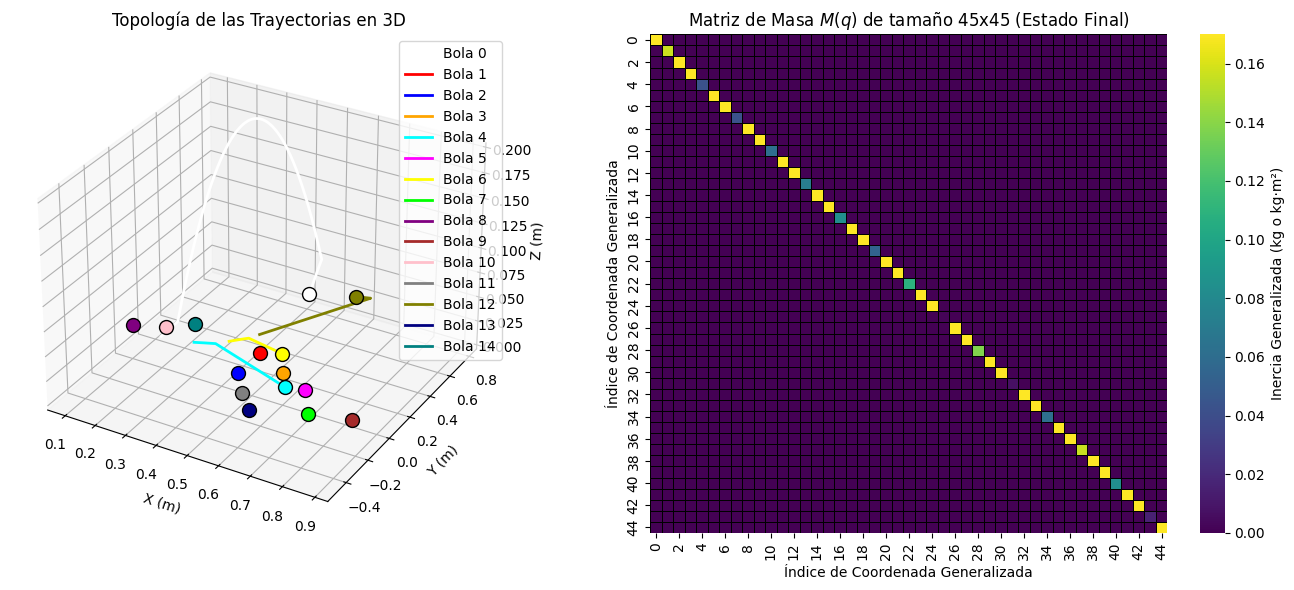

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

class PhysicsMathEngine:
    def __init__(self, k, dt=5e-5, m=0.17, R=0.0285):
        self.k = k
        self.dt = dt
        self.m = m
        self.R = R
        self.g = 9.81
        self.k_stiff = 5e5  
        self.mu = 0.1       
        
        # Estado [k, 6]: r, gamma, z, dr, dgamma, dz
        self.S = np.zeros((k, 6))
        self.history = [] # Para guardar las trayectorias
        
    def compute_exact_derivatives(self, S):
        r, gamma, z = S[:, 0], S[:, 1], S[:, 2]
        dr, dgamma, dz = S[:, 3], S[:, 4], S[:, 5]
        
        # 1. Interacción (Gradiente de -Phi)
        x, y = r * np.cos(gamma), r * np.sin(gamma)
        pos_c = np.stack([x, y, z], axis=1)
        
        diff = pos_c[:, np.newaxis, :] - pos_c[np.newaxis, :, :]
        dist = np.linalg.norm(diff, axis=2) + np.eye(self.k)
        
        overlap = np.maximum(0, 2*self.R - dist)
        f_phi_mag = self.k_stiff * overlap 
        unit_vectors = diff / dist[:, :, np.newaxis]
        f_phi_cart = np.sum(f_phi_mag[:, :, np.newaxis] * unit_vectors, axis=1)

        # 2. Fuerzas Generalizadas (Fricción)
        v_cart_x = dr * np.cos(gamma) - r * dgamma * np.sin(gamma)
        v_cart_y = dr * np.sin(gamma) + r * dgamma * np.cos(gamma)
        v_cart = np.stack([v_cart_x, v_cart_y, dz], axis=1)
        
        f_fric = -self.mu * v_cart
        f_total = f_phi_cart + f_fric

        # 3. Despeje de q''
        fr_ext = f_total[:, 0] * np.cos(gamma) + f_total[:, 1] * np.sin(gamma)
        ddr = (self.m * r * dgamma**2 + fr_ext) / self.m
        
        fgamma_ext = -f_total[:, 0] * np.sin(gamma) + f_total[:, 1] * np.cos(gamma)
        ddgamma = (-2 * self.m * dr * dgamma + fgamma_ext) / (self.m * r + 1e-9)
        
        fz_ext = f_total[:, 2]
        # Gravedad + Fuerza Normal de la mesa (si z <= R, la mesa empuja hacia arriba)
        normal_force = np.where(z <= self.R, self.m * self.g, 0.0)
        ddz = (-self.m * self.g + normal_force + fz_ext) / self.m
        
        return np.stack([ddr, ddgamma, ddz], axis=1)

    def step(self):
        # Guardar estado actual
        self.history.append(self.S.copy())
        
        accel_1 = self.compute_exact_derivatives(self.S)
        v_half = self.S[:, 3:] + 0.5 * self.dt * accel_1
        
        self.S[:, :3] += self.dt * v_half
        self.S[:, 1] = np.mod(self.S[:, 1], 2 * np.pi)
        
        # Rebote con la mesa en z (piso)
        mask_floor = self.S[:, 2] < self.R
        self.S[mask_floor, 2] = self.R
        v_half[mask_floor, 2] *= -0.5 # Disipación al rebotar en la mesa
        
        # Rebote con las bandas (pared cilíndrica en r=1.0)
        mask_wall = self.S[:, 0] > 1.0
        self.S[mask_wall, 0] = 1.0
        v_half[mask_wall, 0] *= -0.8 
        
        accel_2 = self.compute_exact_derivatives(self.S)
        self.S[:, 3:] = v_half + 0.5 * self.dt * accel_2

    def get_mass_matrix(self):
        """Construye la matriz M(q) de 3k x 3k en el instante actual"""
        M = np.zeros((3*self.k, 3*self.k))
        r_current = self.S[:, 0]
        for i in range(self.k):
            # Bloque diagonal para la bola i: [m, m*r^2, m]
            M[3*i, 3*i] = self.m
            M[3*i+1, 3*i+1] = self.m * (r_current[i]**2)
            M[3*i+2, 3*i+2] = self.m
        return M

# --- Simulación ---
k = 15  # Número de bolas para que la gráfica sea clara
sim = PhysicsMathEngine(k=k)

# Condiciones Iniciales
sim.S[:, 0] = np.array([0.2, 0.5, 0.5, 0.6, 0.3, 0.7, 0.4, 0.8, 0.1, 0.9, 0.2, 0.6, 0.5, 0.7, 0.3]) # r
sim.S[:, 1] = np.array([0.0, 0.2, -0.2, 0.0, 0.1, -0.1, 0.3, -0.3, 0.2, -0.2, 0.4, -0.4, 0.5, -0.5, 0.6]) # gamma
sim.S[:, 2] = np.full(k, sim.R) # z (apoyadas en la mesa)

# El "Tacazo" a la bola 0
sim.S[0, 3] = 4.0   # Velocidad radial dr fuerte
sim.S[0, 5] = 1.5   # Un ligero "salto" en z (drásticamente visual en 3D)

print("Integrando el sistema...")
steps = 8000
for _ in range(steps):
    sim.step()

history = np.array(sim.history) # Shape: [steps, k, 6]

# --- Gráfica 1: Trayectorias 3D ---
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
colors = ['white', 'red', 'blue', 'orange', 'cyan', 'magenta', 'yellow', 'lime', 'purple', 'brown', 'pink', 'gray', 'olive', 'navy', 'teal']

for i in range(k):
    r_hist = history[:, i, 0]
    gamma_hist = history[:, i, 1]
    z_hist = history[:, i, 2]
    
    # Conversión a cartesianas para graficar la topología real
    x_hist = r_hist * np.cos(gamma_hist)
    y_hist = r_hist * np.sin(gamma_hist)
    
    ax1.plot(x_hist, y_hist, z_hist, label=f'Bola {i}', color=colors[i], linewidth=2)
    # Marcar posición final
    ax1.scatter(x_hist[-1], y_hist[-1], z_hist[-1], color=colors[i], s=100, edgecolors='black')

ax1.set_title("Topología de las Trayectorias en 3D")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.set_zlabel("Z (m)")
ax1.set_zlim(0, 0.2)
ax1.legend()

# --- Gráfica 2: Matriz de Masa M(q) ---
ax2 = fig.add_subplot(122)
M_final = sim.get_mass_matrix()

# Usamos una escala logarítmica (o ajustada) porque m*r^2 es muy pequeño comparado con m
sns.heatmap(M_final, ax=ax2, cmap="viridis", linewidths=0.5, linecolor='black', 
            cbar_kws={'label': 'Inercia Generalizada (kg o kg·m²)'})

ax2.set_title(f"Matriz de Masa $M(q)$ de tamaño {3*k}x{3*k} (Estado Final)")
ax2.set_xlabel("Índice de Coordenada Generalizada")
ax2.set_ylabel("Índice de Coordenada Generalizada")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

class FullBilliardEngine:
    def __init__(self, k, dt=5e-5):
        self.k = k
        self.dt = dt
        self.m = 0.17
        self.R = 0.0285
        self.g = 9.81
        self.k_stiff = 5e5
        self.mu = 0.1

        # Tensor de inercia general (asimétrico)
        I_base = (2/5)*self.m*self.R**2
        self.I = np.array([
            [I_base, 1e-6, 2e-6],
            [1e-6, I_base*1.01, -1e-6],
            [2e-6, -1e-6, I_base*0.99]
        ])
        self.I_inv = np.linalg.inv(self.I)

        # Estado: [r, gamma, z, dr, dgamma, dz, wx, wy, wz]
        self.S = np.zeros((k, 9))


def apply_impulse(self, i, J, r_impact):
    """
    Aplica impulso tipo delta de Dirac a la bola i
    
    J: vector impulso (3,)
    r_impact: punto de impacto relativo al centro (3,)
    """

    # --- Cambio en velocidad lineal ---
    self.S[i, 3] += (J[0]*np.cos(self.S[i,1]) + J[1]*np.sin(self.S[i,1])) / self.m
    self.S[i, 4] += (-J[0]*np.sin(self.S[i,1]) + J[1]*np.cos(self.S[i,1])) / (self.m*self.S[i,0] + 1e-9)
    self.S[i, 5] += J[2] / self.m

    # --- Cambio en velocidad angular ---
    tau_imp = np.cross(r_impact, J)
    delta_w = self.I_inv @ tau_imp

    self.S[i, 6:9] += delta_w
    
    def compute_derivatives(self, S):
        r, gamma, z = S[:,0], S[:,1], S[:,2]
        dr, dgamma, dz = S[:,3], S[:,4], S[:,5]
        w = S[:,6:9]

        # --- Posiciones ---
        x = r*np.cos(gamma)
        y = r*np.sin(gamma)
        pos = np.stack([x,y,z], axis=1)

        # --- Interacción ---
        diff = pos[:,None,:] - pos[None,:,:]
        dist = np.linalg.norm(diff, axis=2) + np.eye(self.k)
        overlap = np.maximum(0, 2*self.R - dist)

        f_mag = self.k_stiff * overlap
        unit = diff / dist[:,:,None]
        F_phi = np.sum(f_mag[:,:,None]*unit, axis=1)

        # --- Velocidad cartesiana ---
        vx = dr*np.cos(gamma) - r*dgamma*np.sin(gamma)
        vy = dr*np.sin(gamma) + r*dgamma*np.cos(gamma)
        v = np.stack([vx,vy,dz], axis=1)

        # --- Velocidad relativa ---
        v_rel = np.zeros_like(v)
        v_rel[:,0] = v[:,0] - self.R*w[:,1]
        v_rel[:,1] = v[:,1] + self.R*w[:,0]
        v_rel[:,2] = v[:,2]

        # --- Fricción ---
        F_fric = -self.mu * v_rel

        F_total = F_phi + F_fric

        # --- Traslación ---
        Fr = F_total[:,0]*np.cos(gamma) + F_total[:,1]*np.sin(gamma)
        Fg = -F_total[:,0]*np.sin(gamma) + F_total[:,1]*np.cos(gamma)

        ddr = (self.m*r*dgamma**2 + Fr)/self.m
        ddgamma = (-2*self.m*dr*dgamma + Fg)/(self.m*r + 1e-9)

        normal = np.where(z <= self.R, self.m*self.g, 0)
        ddz = (F_total[:,2] - self.m*self.g + normal)/self.m

        # --- Torque ---
        tau = np.zeros_like(w)
        tau[:,0] = self.R * F_total[:,1]
        tau[:,1] = -self.R * F_total[:,0]

        # --- Rotación (Euler) ---
        Iw = (self.I @ w.T).T
        cross = np.cross(w, Iw)
        dw = (self.I_inv @ (tau - cross).T).T

        return np.hstack([ddr[:,None], ddgamma[:,None], ddz[:,None], dw])

    def step(self):
        acc1 = self.compute_derivatives(self.S)
        v_half = self.S[:,3:] + 0.5*self.dt*acc1

        self.S[:,:3] += self.dt*v_half[:,:3]
        self.S[:,1] = np.mod(self.S[:,1], 2*np.pi)

        acc2 = self.compute_derivatives(self.S)
        self.S[:,3:] = v_half + 0.5*self.dt*acc2

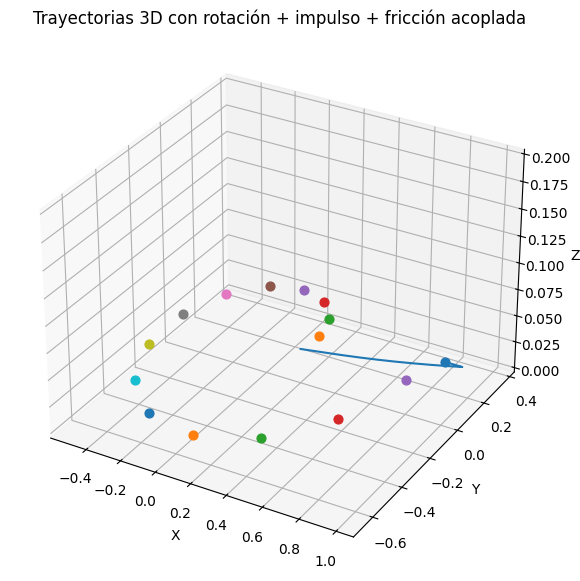

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class FullBilliardEngine:
    def __init__(self, k, dt=5e-5):
        self.k = k
        self.dt = dt
        self.m = 0.17
        self.R = 0.0285
        self.g = 9.81
        self.k_stiff = 5e5
        self.mu = 0.08

        # Tensor de inercia general (asimétrico)
        I_base = (2/5)*self.m*self.R**2
        self.I = np.array([
            [I_base, 2e-6, -1e-6],
            [2e-6, I_base*1.02, 1e-6],
            [-1e-6, 1e-6, I_base*0.98]
        ])
        self.I = (self.I + self.I.T)/2
        self.I_inv = np.linalg.inv(self.I)

        # Estado: [r, gamma, z, dr, dgamma, dz, wx, wy, wz]
        self.S = np.zeros((k, 9))
        self.history = []

    def compute_derivatives(self, S):
        r, gamma, z = S[:,0], S[:,1], S[:,2]
        dr, dgamma, dz = S[:,3], S[:,4], S[:,5]
        w = S[:,6:9]

        # --- Posiciones cartesianas ---
        x = r*np.cos(gamma)
        y = r*np.sin(gamma)
        pos = np.stack([x,y,z], axis=1)

        # --- Interacción tipo potencial ---
        diff = pos[:,None,:] - pos[None,:,:]
        dist = np.linalg.norm(diff, axis=2) + np.eye(self.k)
        overlap = np.maximum(0, 2*self.R - dist)

        f_mag = self.k_stiff * overlap
        unit = diff / dist[:,:,None]
        F_phi = np.sum(f_mag[:,:,None]*unit, axis=1)

        # --- Velocidad cartesiana ---
        vx = dr*np.cos(gamma) - r*dgamma*np.sin(gamma)
        vy = dr*np.sin(gamma) + r*dgamma*np.cos(gamma)
        v = np.stack([vx,vy,dz], axis=1)

        # --- Velocidad relativa (clave del acoplamiento) ---
        v_rel = np.zeros_like(v)
        v_rel[:,0] = v[:,0] - self.R*w[:,1]
        v_rel[:,1] = v[:,1] + self.R*w[:,0]
        v_rel[:,2] = v[:,2]

        # --- Fricción ---
        F_fric = -self.mu * v_rel

        F_total = F_phi + F_fric

        # --- Proyección a coordenadas generalizadas ---
        Fr = F_total[:,0]*np.cos(gamma) + F_total[:,1]*np.sin(gamma)
        Fg = -F_total[:,0]*np.sin(gamma) + F_total[:,1]*np.cos(gamma)

        ddr = (self.m*r*dgamma**2 + Fr)/self.m
        ddgamma = (-2*self.m*dr*dgamma + Fg)/(self.m*r + 1e-9)

        normal = np.where(z <= self.R, self.m*self.g, 0)
        ddz = (F_total[:,2] - self.m*self.g + normal)/self.m

        # --- Torque ---
        tau = np.zeros_like(w)
        tau[:,0] = self.R * F_total[:,1]
        tau[:,1] = -self.R * F_total[:,0]

        # --- Rotación (Euler rígido) ---
        Iw = (self.I @ w.T).T
        cross = np.cross(w, Iw)
        dw = (self.I_inv @ (tau - cross).T).T

        return np.hstack([ddr[:,None], ddgamma[:,None], ddz[:,None], dw])

    def step(self):
        self.history.append(self.S.copy())

        acc1 = self.compute_derivatives(self.S)
        v_half = self.S[:,3:] + 0.5*self.dt*acc1

        self.S[:,:3] += self.dt*v_half[:,:3]
        self.S[:,1] = np.mod(self.S[:,1], 2*np.pi)

        # Piso
        mask_floor = self.S[:,2] < self.R
        self.S[mask_floor,2] = self.R
        v_half[mask_floor,2] *= -0.4

        # Pared circular
        mask_wall = self.S[:,0] > 1.0
        self.S[mask_wall,0] = 1.0
        v_half[mask_wall,0] *= -0.7

        acc2 = self.compute_derivatives(self.S)
        self.S[:,3:] = v_half + 0.5*self.dt*acc2

    def apply_impulse(self, i, J, r_impact):
        gamma = self.S[i,1]

        # Traslación
        self.S[i,3] += (J[0]*np.cos(gamma) + J[1]*np.sin(gamma)) / self.m
        self.S[i,4] += (-J[0]*np.sin(gamma) + J[1]*np.cos(gamma)) / (self.m*self.S[i,0] + 1e-9)
        self.S[i,5] += J[2]/self.m

        # Rotación
        tau = np.cross(r_impact, J)
        delta_w = self.I_inv @ tau
        self.S[i,6:9] += delta_w


# =====================
# SIMULACIÓN
# =====================

k = 15
sim = FullBilliardEngine(k)

# Configuración inicial
sim.S[:,0] = np.linspace(0.2,0.8,k)
sim.S[:,1] = np.linspace(0,2*np.pi,k)
sim.S[:,2] = sim.R

# TACAZO (delta de Dirac)
J = np.array([0.6, 0.1, 0.0])
r_impact = np.array([0,0,-sim.R])
sim.apply_impulse(0, J, r_impact)

# Integración
steps = 6000
for _ in range(steps):
    sim.step()

history = np.array(sim.history)

# =====================
# GRÁFICA 3D
# =====================

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for i in range(k):
    r = history[:,i,0]
    gamma = history[:,i,1]
    z = history[:,i,2]

    x = r*np.cos(gamma)
    y = r*np.sin(gamma)

    ax.plot(x,y,z)
    ax.scatter(x[-1],y[-1],z[-1], s=40)

ax.set_title("Trayectorias 3D con rotación + impulso + fricción acoplada")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_zlim(0,0.2)

plt.show()

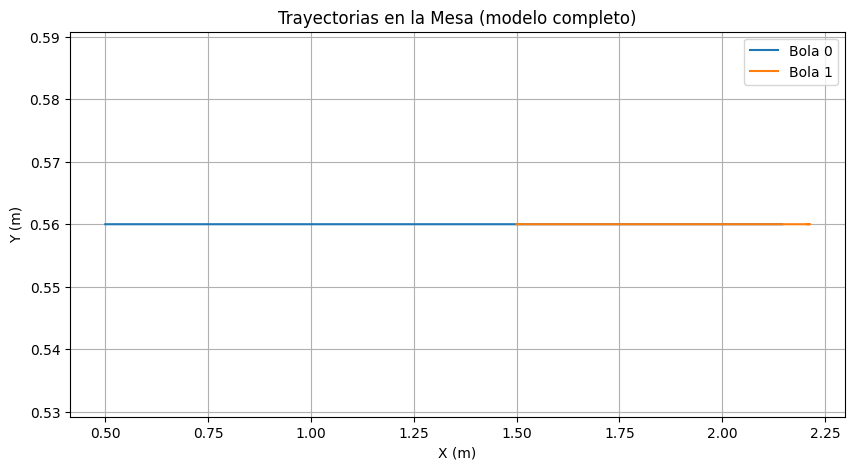

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros Globales
M = 0.170
R = 0.028575
G = 9.81
I = 0.4 * M * R**2
MU_S = 0.20
MU_R = 0.01
K_P = 1e5
C_D = 50.0

class BilliardSystem:
    def __init__(self, num_balls, table_size=(2.24, 1.12)):
        self.k = num_balls
        self.table_w, self.table_h = table_size
        self.state = np.zeros((num_balls, 9))
        self.colors = plt.cm.jet(np.linspace(0, 1, num_balls))

    def set_ball(self, idx, pos, vel, omega):
        self.state[idx, 0:3] = pos
        self.state[idx, 3:6] = vel
        self.state[idx, 6:9] = omega

    def get_forces(self, state):
        forces = np.zeros((self.k, 3))
        torques = np.zeros((self.k, 3))
        
        r_cp = np.array([0.0, 0.0, -R])  # ✔ punto de contacto correcto
        
        for i in range(self.k):
            pos_i = state[i, 0:3]
            vel_i = state[i, 3:6]
            omega_i = state[i, 6:9]
            
            # --- 1. Fricción ---
            u = vel_i + np.cross(omega_i, r_cp)
            u_mag = np.linalg.norm(u)
            
            if u_mag > 1e-6:
                f_fric = -MU_S * M * G * (u / u_mag)
                forces[i] += f_fric
                torques[i] += np.cross(r_cp, f_fric)
            else:
                v_mag = np.linalg.norm(vel_i)
                if v_mag > 1e-6:
                    f_roll = -(5/7) * MU_R * M * G * (vel_i / v_mag)
                    forces[i] += f_roll
                    torques[i] += np.cross(r_cp, f_roll)

            # --- 2. Gravedad ---
            forces[i, 2] -= M * G

            # --- 3. Colisiones bola-bola ---
            for j in range(i + 1, self.k):
                pos_j = state[j, 0:3]
                vel_j = state[j, 3:6]

                diff = pos_i - pos_j
                dist = np.linalg.norm(diff) + 1e-12

                if dist < 2*R:
                    overlap = 2*R - dist
                    normal = diff / dist
                    v_rel = vel_i - vel_j

                    f_mag = K_P * overlap - C_D * np.dot(v_rel, normal)
                    f_col = max(0, f_mag) * normal

                    forces[i] += f_col
                    forces[j] -= f_col

            # --- 4. Paredes ---
            # Izquierda (x=0)
            if pos_i[0] < R:
                forces[i, 0] += K_P*(R - pos_i[0]) - C_D*vel_i[0]

            # Derecha
            if pos_i[0] > self.table_w - R:
                forces[i, 0] -= K_P*(pos_i[0] - (self.table_w - R)) + C_D*vel_i[0]

            # Abajo (y=0)
            if pos_i[1] < R:
                forces[i, 1] += K_P*(R - pos_i[1]) - C_D*vel_i[1]

            # Arriba
            if pos_i[1] > self.table_h - R:
                forces[i, 1] -= K_P*(pos_i[1] - (self.table_h - R)) + C_D*vel_i[1]

            # Suelo (z=0)
            if pos_i[2] < 0:
                forces[i, 2] += K_P*(-pos_i[2]) - C_D*vel_i[2]

        return forces, torques

    def derivative(self, state_flat):
        state = state_flat.reshape((self.k, 9))
        forces, torques = self.get_forces(state)

        deriv = np.zeros_like(state)

        deriv[:, 0:3] = state[:, 3:6]
        deriv[:, 3:6] = forces / M
        deriv[:, 6:9] = torques / I

        return deriv.flatten()


def run_simulation(system, t_max=2.0, dt=0.001):
    t = np.arange(0, t_max, dt)
    history = np.zeros((len(t), system.k, 9))
    current_state = system.state.flatten()
    
    for i in range(len(t)):
        history[i] = current_state.reshape((system.k, 9))

        k1 = system.derivative(current_state)
        k2 = system.derivative(current_state + 0.5 * dt * k1)
        k3 = system.derivative(current_state + 0.5 * dt * k2)
        k4 = system.derivative(current_state + dt * k3)

        current_state += (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

    return t, history


# =====================
# EJEMPLO
# =====================

pool = BilliardSystem(num_balls=2)

pool.set_ball(0, [0.5, 0.56, 0.0], [3.0, 0.0, 0.0], [0, 0, 10.0])
pool.set_ball(1, [1.5, 0.56, 0.0], [0.0, 0.0, 0.0], [0, 0, 0.0])

t, data = run_simulation(pool, t_max=1.5)

# --- Plot ---
plt.figure(figsize=(10,5))
for b in range(pool.k):
    plt.plot(data[:, b, 0], data[:, b, 1], label=f'Bola {b}')

plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Trayectorias en la Mesa (modelo completo)')
plt.legend()
plt.grid(True)
plt.show()